We want to create out-of-distribution (OOD) test/validation data. OOD data would be a previously unseen stimulation condition - cell type combination which will demonstrate if the model generalizes. 

In [1]:
import os
from typing import Optional, Dict, List

import pandas as pd
import numpy as np
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io

In [3]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'

In [4]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
# adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)



/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Let's take a look at how the variables of interest are distributed across the dataset:

In [5]:
contingency_table = pd.crosstab(tf_adata.obs['stim'], tf_adata.obs['seurat_annotations'], 
                                margins=True, margins_name="Total")
contingency_table

seurat_annotations,B,B Activated,CD4 Memory T,CD4 Naive T,CD8 T,CD14 Mono,CD16 Mono,DC,Eryth,Mk,NK,T activated,pDC,Total
stim,,,,,,,,,,,,,,
CTRL,407,185,859,978,352,2215,507,258,23,115,298,300,51,6548
STIM,571,203,903,1526,462,2147,537,214,32,121,321,333,81,7451
Total,978,388,1762,2504,814,4362,1044,472,55,236,619,633,132,13999


<Axes: ylabel='Count'>

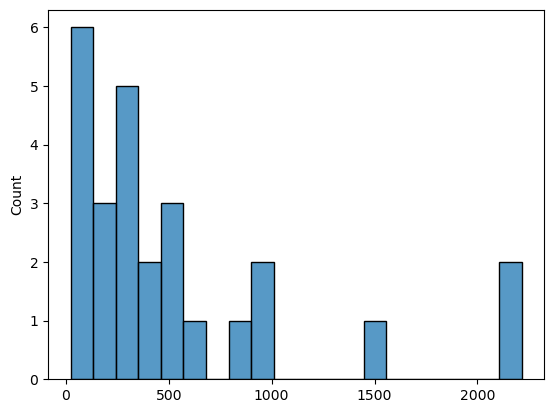

In [6]:
viz_df = contingency_table.drop(columns = ['Total'], index = ['Total'], inplace = False)
sns.histplot(viz_df.values.flatten(), bins=20)

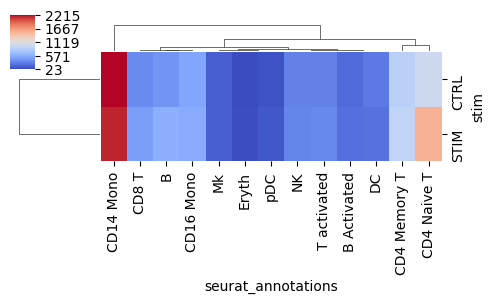

In [7]:
sns.clustermap(viz_df, figsize=(5,3), cmap = 'coolwarm', 
              cbar_kws={"ticks": np.linspace(viz_df.min().min(), viz_df.max().max(), 5)})

We want to generate a train-validation-test split of 70%-15%-15%. So, we'll first generate a (train + validation) - test split of 85% - 15%. Each of the train and validation will include OOD data only. The train will contain each individual condition in both the validation and split, but not the combinations (OOD) present in the validation or test. 

In [8]:
train_frac, val_frac, test_frac = 0.7, 0.15, 0.15

In [9]:
def ood_split(tf_adata, 
             train_frac: float, 
             condition_cols: str, 
             max_iter: int = 1000, 
             seed: int = 888, 
             deviation_thresh: float = 0.025, 
             include_train_cond: Optional[Dict[str, List]] = None):
    """Generate an OOD train test split, where both the condition data and the single-cells have approximately
    the specified split.

    Parameters
    ----------
    tf_adata : 
        AnnData object of TF activity
    train_frac : float
        the fraction of the data going to training
    condition_cols : List[str]
        the metadata column to consider the OOD split on
    max_iter : int, optional
        total iterations to try to identify a suitable split, by default 1000
    seed : int, optional
        random state variable, by default 888
    deviation_thresh : float, optional
        extent to which to allow the single-cell split to deviate from the specified `train_frac split`, by default 0.025
    include_train_cond : Optional[Dict[str, List]]
        a dictionary with keys for each column in `condition_cols` and keys as a list that represents a subset
        of values in that column that must be included in the training set. 
    """

    test_frac = 1 - train_frac
    
    condition_combs = tf_adata.obs[condition_cols].apply(lambda row: '^'.join(row.astype(str)), axis=1)
    unique_conditions = condition_combs.drop_duplicates(keep = 'first', inplace = False).tolist()

    train_frac_deviation = np.inf
    zero_shot_bool = False
    
    if include_train_cond is not None:
        if sorted(set(include_train_cond).intersection(condition_cols)) != sorted(condition_cols):
            raise ValueError('Keys for `include_train_cond` must be the same as `condition_cols`')
        for cond, cond_vals in include_train_cond.items():
            if not set(cond_vals).issubset(tf_adata.obs[cond].tolist()):
                raise ValueError('The conditions to include in training for ' + cond + ' are not present in the metadata.')
        ict_bool = False
    else:
        ict_bool = True

    counter = 0
    while (train_frac_deviation > deviation_thresh or not zero_shot_bool or not ict_bool) and (counter < max_iter):
        # ood at categorical level
        train_cond, test_cond = train_test_split(unique_conditions, test_size = test_frac, random_state = seed + counter, shuffle = True)
        train_cells = condition_combs[condition_combs.isin(train_cond)].index.tolist()
        test_cells = condition_combs[condition_combs.isin(test_cond)].index.tolist()

        train_frac_actual = len(train_cells)/tf_adata.shape[0]
        train_frac_deviation = abs(train_frac_actual - train_frac)
        
        # ensure that all individual conditions are seen atleast once (it's the combination of conditions that's unique)
        train_cond_map = {}
        for idx, cond in enumerate(condition_cols):
            train_cond_map[cond] = {tc.split('^')[idx] for tc in train_cond}

        test_cond_map = {}
        for idx, cond in enumerate(condition_cols):
            test_cond_map[cond] = {tc.split('^')[idx] for tc in test_cond}

        zero_shots = [len(test_cond_map[cond].difference(train_cond_map[cond])) for cond in condition_cols]    
        zero_shot_bool = all(value == 0 for value in zero_shots)
        
        if include_train_cond is not None:
            ict_conds = [len(include_train_cond[cond].difference(cond_vals)) for cond, cond_vals in train_cond_map.items()]
            ict_bool = any(value == 0 for value in ict_conds)
        
        counter += 1
    
    if counter <= max_iter:
        return train_cells, test_cells, train_cond, test_cond
    else:
        return None, None, None, None

In [10]:
condition_cols = ['stim', 'seurat_annotations']
train_val_cells, test_cells, train_val_cond, test_cond = ood_split(tf_adata, 
                                                           train_frac = train_frac + val_frac, 
                                                           condition_cols = condition_cols, 
                                                           max_iter = 1000, seed = seed, deviation_thresh = 0.025, 
                                                                  include_train_cond = None)

# ensure that the training split includes individual conditions for test data to prevent zero-shot
# validation data handled internally by function to prevent zero-shot)
include_train_cond = {}
for idx, cond in enumerate(condition_cols):
    include_train_cond[cond] = {tc.split('^')[idx] for tc in test_cond}

Do the k-fold splitting of the train-val data while maintaining OOD and ensuring each split is unique:

In [12]:
k = 5
counter,i = 0, 0

max_iter_inner = 1000
max_iter_outer = k*2

val_conds_all = [set()]*k
k_fold_cells = {}

while (i < k) and (counter < max_iter_outer):
    train_cells, val_cells, train_cond, val_cond = ood_split(tf_adata[train_val_cells,:], 
                                                               train_frac = train_frac/(train_frac + val_frac), 
                                                               condition_cols = ['stim', 'seurat_annotations'], 
                                                               max_iter = max_iter_inner, 
                                                             seed = seed + (counter * max_iter_inner) , 
                                                             deviation_thresh = 0.025, 
                                                            include_train_cond = include_train_cond)
    different_conds = [len(set(val_cond).difference(vca)) for vca in val_conds_all]
    if all(value != 0 for value in different_conds): # ensure that the new validation is not the exact same as any other
        val_conds_all[i] = val_cond
        k_fold_cells[i] = {'train_cells': train_cells, 
                          'val_cells': val_cells, 
                          'train_cond': train_cond, 
                          'val_cond': val_cond}
        i += 1
        
        
    counter += 1
    

In [15]:
def write_list(list_, fn):
    with open(fn, 'w') as file:
        for item in list_:
            file.write(f"{item}\n")

In [16]:
if not os.path.isdir(os.path.join(data_path, 'processed', 'data_split_barcodes')):
    os.mkdir(os.path.join(data_path, 'processed', 'data_split_barcodes'))

In [17]:
write_list(test_cells, fn = os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt'))
fn = os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_k_.txt')
for k, k_train_val in k_fold_cells.items():
    fn_ = fn.replace('k_', str(k) + '_')
    for split_type, barcodes in k_train_val.items():
        fn__ = fn_.replace('.txt', split_type + '.txt')
        write_list(barcodes, fn__)